# Scenario 1 – User-Based Collaborative Filtering
# 24BAD067 Manoj M
## Movie Recommendation System using KNN & Cosine Similarity
### Dataset: MovieLens 100K

---
## Step 1: Import Required Libraries

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2: Load the MovieLens Dataset

> **Download Instructions:**  
> 1. Go to https://www.kaggle.com/datasets/grouplens/movielens-100k  
> 2. Download and unzip into a folder called `ml-100k/`  
> 3. Place it in the same directory as this notebook  
>
> **OR** use the built-in fetch below (requires internet access):

In [39]:
import os

DATA_PATH = '/Users/manojmj/PycharmProjects/machinelearning subject/expno9/ml-100k'

# ⚠️  Manual step required — network download is disabled.
# 1. Go to: https://grouplens.org/datasets/movielens/100k/
# 2. Click 'ml-100k.zip' to download
# 3. Unzip it — you will get a folder called 'ml-100k'
# 4. Place that folder in the SAME directory as this notebook
# Then re-run this cell.

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Dataset folder 'ml-100k' not found. "
        "Download it from https://grouplens.org/datasets/movielens/100k/ "
        "and place the unzipped folder next to this notebook."
    )
print('Dataset found:', DATA_PATH)

# Column names for the ratings file
ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
movies_cols  = ['movie_id', 'title', 'release_date', 'video_release_date',
                'IMDb_URL'] + [f'genre_{i}' for i in range(19)]

# Load ratings (u.data) and movies (u.item)
ratings = pd.read_csv(f'{DATA_PATH}/u.data', sep='\t',
                      names=ratings_cols, encoding='latin-1')
movies  = pd.read_csv(f'{DATA_PATH}/u.item', sep='|',
                      names=movies_cols,  encoding='latin-1')

print(f'Ratings shape : {ratings.shape}')
print(f'Movies  shape : {movies.shape}')
ratings.head()

Dataset found: /Users/manojmj/PycharmProjects/machinelearning subject/expno9/ml-100k
Ratings shape : (100000, 4)
Movies  shape : (1682, 24)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


---
## Step 3: Data Inspection & Preprocessing

In [40]:
print('=== Ratings Info ===')
print(ratings.info())
print('\n=== Ratings Describe ===')
print(ratings.describe())
print('\n=== Missing Values ===')
print(ratings.isnull().sum())

=== Ratings Info ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

=== Ratings Describe ===
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08

=

Total users    : 943
Total movies   : 1682
Total ratings  : 100000
Rating range   : 1 – 5
Mean rating    : 3.53


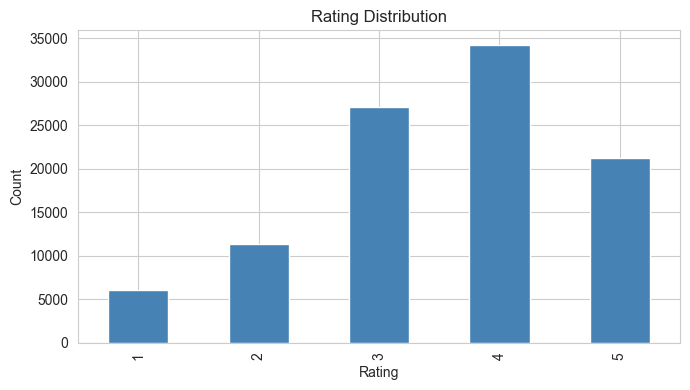

In [41]:
# Basic statistics
print(f"Total users    : {ratings['user_id'].nunique()}")
print(f"Total movies   : {ratings['movie_id'].nunique()}")
print(f"Total ratings  : {len(ratings)}")
print(f"Rating range   : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Mean rating    : {ratings['rating'].mean():.2f}")

# Rating distribution
plt.figure(figsize=(7, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [42]:
# Merge ratings with movie titles
df = ratings.merge(movies[['movie_id', 'title']], on='movie_id', how='left')
print('Merged dataframe shape:', df.shape)
df.head()

Merged dataframe shape: (100000, 5)


,user_id,movie_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


---
## Step 4: Create User-Item Matrix

In [43]:
# Pivot: rows = users, columns = movies
user_item_matrix = df.pivot_table(index='user_id', columns='title',
                                   values='rating')

print('User-Item matrix shape:', user_item_matrix.shape)
user_item_matrix.head()

User-Item matrix shape: (943, 1664)


title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN


---
## Step 5: Handle Missing Values

In [44]:
# Sparsity analysis
total_cells   = user_item_matrix.shape[0] * user_item_matrix.shape[1]
missing_cells = user_item_matrix.isnull().sum().sum()
sparsity      = (missing_cells / total_cells) * 100

print(f'Total cells    : {total_cells:,}')
print(f'Missing cells  : {missing_cells:,}')
print(f'Sparsity       : {sparsity:.2f}%')

# Fill NaN with 0 for similarity computation
user_item_filled = user_item_matrix.fillna(0)
print('\nMissing values after fill:', user_item_filled.isnull().sum().sum())

Total cells    : 1,569,152
Missing cells  : 1,469,459
Sparsity       : 93.65%

Missing values after fill: 0


---
## Step 6: Compute Cosine Similarity Between Users

In [45]:
# Cosine similarity on the filled matrix
user_similarity = cosine_similarity(user_item_filled)
user_sim_df     = pd.DataFrame(user_similarity,
                                index=user_item_matrix.index,
                                columns=user_item_matrix.index)

print('User Similarity matrix shape:', user_sim_df.shape)
user_sim_df.iloc[:5, :5]

User Similarity matrix shape: (943, 943)


user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.168937,0.048388,0.064561,0.379670
2,0.168937,1.000000,0.113393,0.179694,0.073623
3,0.048388,0.113393,1.000000,0.349781,0.021592
4,0.064561,0.179694,0.349781,1.000000,0.031804
5,0.379670,0.073623,0.021592,0.031804,1.000000


---
## Step 7: Identify Top-N Similar Users

In [46]:
def get_top_n_similar_users(user_id, similarity_df, n=10):
    """
    Return the top-N most similar users to the given user_id.
    Excludes the user themselves.
    """
    sim_scores = similarity_df[user_id].drop(index=user_id)
    top_users  = sim_scores.nlargest(n)
    return top_users

# Example: Top 10 users similar to User 1
TARGET_USER = 1
top_similar = get_top_n_similar_users(TARGET_USER, user_sim_df, n=10)
print(f'Top 10 users similar to User {TARGET_USER}:')
print(top_similar.to_frame(name='Cosine Similarity'))

Top 10 users similar to User 1:
         Cosine Similarity
user_id                   
916               0.566293
864               0.549277
457               0.541364
92                0.539415
268               0.538883
435               0.535961
738               0.528695
429               0.527610
303               0.523387
276               0.523277


---
## Step 8: Predict Ratings for Unseen Movies

In [47]:
def predict_ratings(user_id, user_item_df, similarity_df, n_neighbors=10):
    """
    Predict ratings for movies not yet rated by user_id.
    Uses weighted average of top-N neighbours' ratings.
    """
    # Get top-N similar users
    top_users   = get_top_n_similar_users(user_id, similarity_df, n=n_neighbors)
    sim_weights = top_users.values                      # shape (n,)
    neighbor_ratings = user_item_df.loc[top_users.index] # shape (n, movies)

    # Movies already rated by the target user
    rated_movies = user_item_df.loc[user_id].dropna().index

    # Weighted average prediction
    weighted_sum  = neighbor_ratings.T.dot(sim_weights)
    sim_total     = np.where(neighbor_ratings.T.notna().dot(sim_weights) == 0,
                             1e-9,
                             neighbor_ratings.T.notna().dot(sim_weights))
    predicted     = weighted_sum / sim_total

    # Return only unrated movies
    predicted_series = pd.Series(predicted, index=user_item_df.columns)
    unrated_preds    = predicted_series.drop(index=rated_movies, errors='ignore')
    return unrated_preds.sort_values(ascending=False)

predicted_ratings = predict_ratings(TARGET_USER, user_item_matrix, user_sim_df, n_neighbors=10)
print(f'Predicted ratings for User {TARGET_USER} (top 10):')
print(predicted_ratings.head(10))

Predicted ratings for User 1 (top 10):
title
Stand by Me (1986)                             3.696740
E.T. the Extra-Terrestrial (1982)              3.694561
Speed (1994)                                   3.403344
Mission: Impossible (1996)                     3.198606
'Til There Was You (1997)                           NaN
1-900 (1994)                                        NaN
187 (1997)                                          NaN
2 Days in the Valley (1996)                         NaN
3 Ninjas: High Noon At Mega Mountain (1998)         NaN
39 Steps, The (1935)                                NaN
dtype: float64


---
## Step 9: Generate Top-N Recommendations

In [48]:
def recommend_movies(user_id, user_item_df, similarity_df, n_recommendations=10, n_neighbors=10):
    """
    Return top-N movie recommendations for a user.
    """
    preds = predict_ratings(user_id, user_item_df, similarity_df, n_neighbors)
    return preds.head(n_recommendations)

top10_recs = recommend_movies(TARGET_USER, user_item_matrix, user_sim_df,
                               n_recommendations=10)

print(f'\n🎬 Top 10 Movie Recommendations for User {TARGET_USER}:')
print('=' * 55)
for rank, (movie, score) in enumerate(top10_recs.items(), 1):
    print(f'  {rank:2}. {movie[:45]:<45}  (score: {score:.3f})')


🎬 Top 10 Movie Recommendations for User 1:
   1. Stand by Me (1986)                             (score: 3.697)
   2. E.T. the Extra-Terrestrial (1982)              (score: 3.695)
   3. Speed (1994)                                   (score: 3.403)
   4. Mission: Impossible (1996)                     (score: 3.199)
   5. 'Til There Was You (1997)                      (score: nan)
   6. 1-900 (1994)                                   (score: nan)
   7. 187 (1997)                                     (score: nan)
   8. 2 Days in the Valley (1996)                    (score: nan)
   9. 3 Ninjas: High Noon At Mega Mountain (1998)    (score: nan)
  10. 39 Steps, The (1935)                           (score: nan)


---
## Step 10: Evaluate – RMSE & MAE

In [49]:
# Train/test split on the ratings DataFrame
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# Build user-item matrix from training data only
train_matrix = train_data.pivot_table(index='user_id', columns='title',
                                       values='rating').fillna(0)
train_sim    = pd.DataFrame(cosine_similarity(train_matrix),
                             index=train_matrix.index,
                             columns=train_matrix.index)

# Predict for test users
actual, predicted = [], []
test_users = test_data['user_id'].unique()[:50]   # limit to 50 users for speed

for uid in test_users:
    if uid not in train_matrix.index:
        continue
    user_test_rows = test_data[test_data['user_id'] == uid]
    preds = predict_ratings(uid,
                             train_matrix.replace(0, np.nan),
                             train_sim, n_neighbors=10)
    for _, row in user_test_rows.iterrows():
        movie = row['title']
        if movie in preds.index and not np.isnan(preds[movie]):
            actual.append(row['rating'])
            predicted.append(preds[movie])

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae  = mean_absolute_error(actual, predicted)

print(f'Evaluation on {len(actual)} predictions')
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')

Evaluation on 19 predictions
RMSE : 0.7678
MAE  : 0.6101


---
## Analysis & Visualizations
### Visualization 1 – Heatmap of User-Item Matrix (subset)

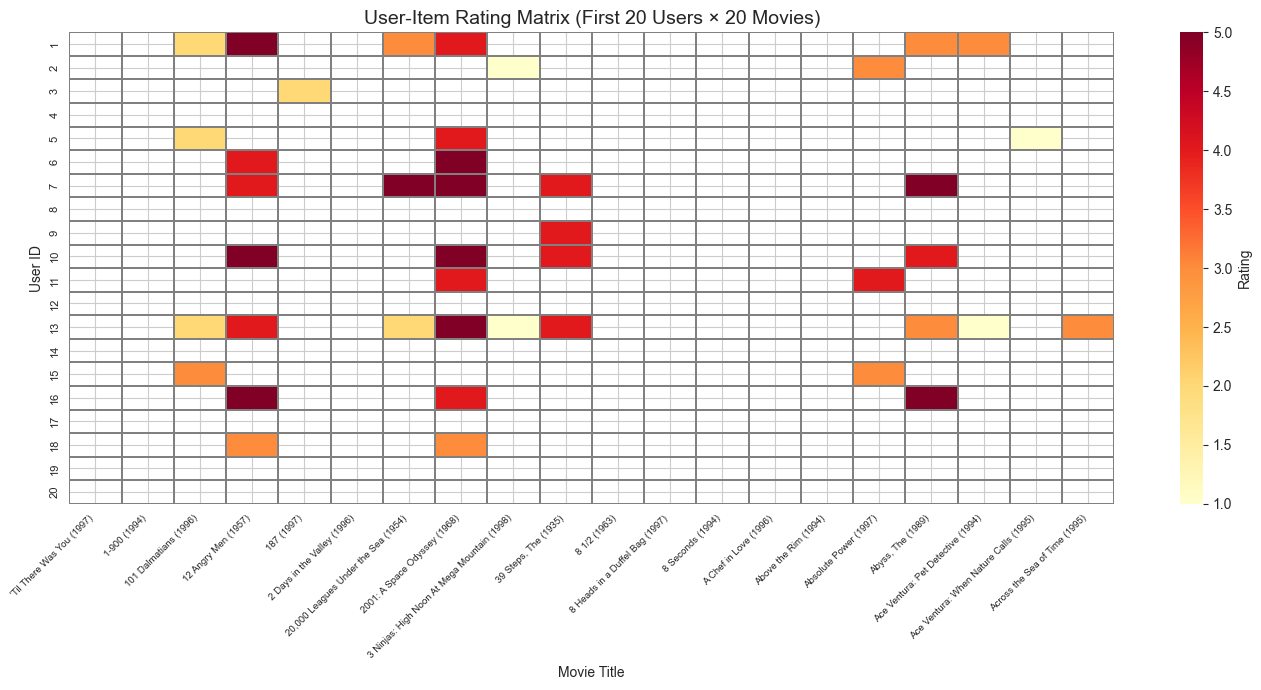

Matrix Sparsity: 93.65%  — most cells are empty (NaN / grey)


In [50]:
# Show a 20x20 subset for readability
subset = user_item_matrix.iloc[:20, :20]

plt.figure(figsize=(14, 7))
sns.heatmap(subset, cmap='YlOrRd', linewidths=0.3, linecolor='gray',
            cbar_kws={'label': 'Rating'}, annot=False, mask=subset.isnull())
plt.title('User-Item Rating Matrix (First 20 Users × 20 Movies)', fontsize=14)
plt.xlabel('Movie Title')
plt.ylabel('User ID')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Matrix Sparsity: {sparsity:.2f}%  — most cells are empty (NaN / grey)')

### Visualization 2 – User Similarity Matrix (subset)

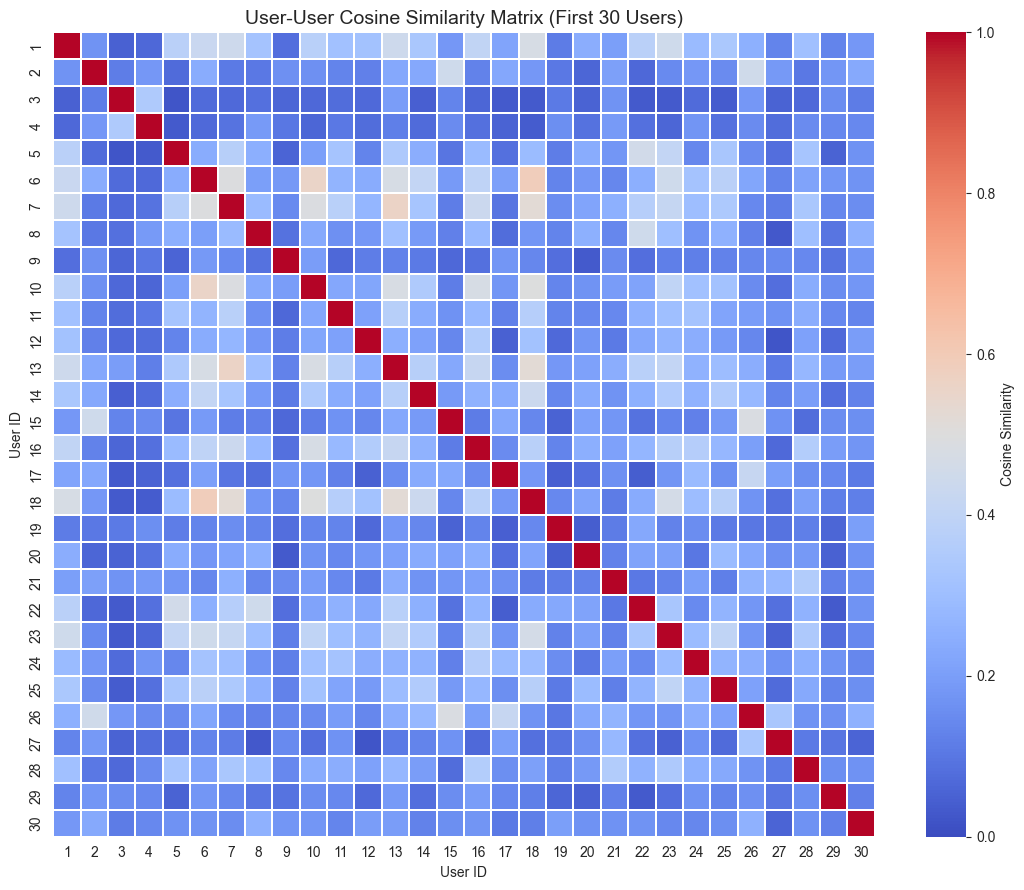

In [51]:
# Show similarity for first 30 users
sim_subset = user_sim_df.iloc[:30, :30]

plt.figure(figsize=(11, 9))
sns.heatmap(sim_subset, cmap='coolwarm', annot=False,
            vmin=0, vmax=1, cbar_kws={'label': 'Cosine Similarity'},
            linewidths=0.2)
plt.title('User-User Cosine Similarity Matrix (First 30 Users)', fontsize=14)
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

### Visualization 3 – Top Recommended Movies (Bar Chart)

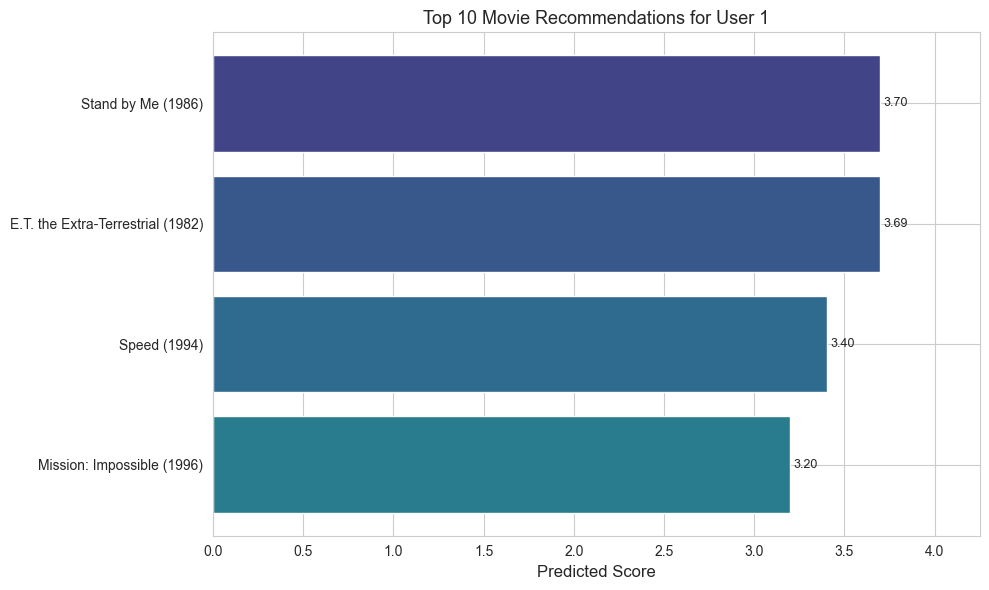

In [52]:
top10 = recommend_movies(TARGET_USER, user_item_matrix, user_sim_df, n_recommendations=10)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(top10)))
bars = plt.barh([t[:40] for t in top10.index[::-1]],
                top10.values[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Predicted Score', fontsize=12)
plt.title(f'Top 10 Movie Recommendations for User {TARGET_USER}', fontsize=13)
plt.xlim(0, top10.max() * 1.15)
for bar, val in zip(bars, top10.values[::-1]):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Visualization 4 – Similarity Distribution & Sparsity Analysis

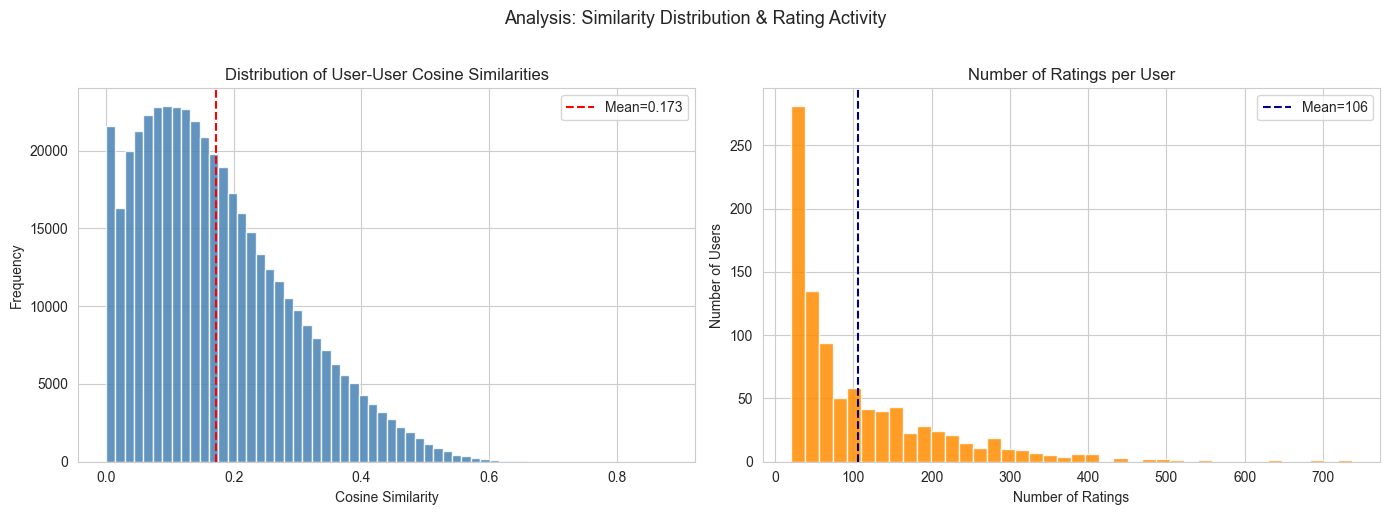

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Cosine similarity distribution (off-diagonal) ---
upper_tri = user_similarity[np.triu_indices_from(user_similarity, k=1)]
axes[0].hist(upper_tri, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(upper_tri.mean(), color='red', linestyle='--', label=f'Mean={upper_tri.mean():.3f}')
axes[0].set_title('Distribution of User-User Cosine Similarities')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# --- Plot 2: Ratings per user ---
ratings_per_user = df.groupby('user_id')['rating'].count()
axes[1].hist(ratings_per_user, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(ratings_per_user.mean(), color='navy', linestyle='--',
                label=f'Mean={ratings_per_user.mean():.0f}')
axes[1].set_title('Number of Ratings per User')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].legend()

plt.suptitle('Analysis: Similarity Distribution & Rating Activity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Analysis Observations

In [54]:
# ---- Summary ----
print('=' * 60)
print('  USER-BASED COLLABORATIVE FILTERING – SUMMARY')
print('=' * 60)
print(f'  Dataset        : MovieLens 100K')
print(f'  Users          : {ratings["user_id"].nunique()}')
print(f'  Movies         : {ratings["movie_id"].nunique()}')
print(f'  Total Ratings  : {len(ratings):,}')
print(f'  Matrix Size    : {user_item_matrix.shape}')
print(f'  Sparsity       : {sparsity:.2f}%')
print(f'  RMSE           : {rmse:.4f}')
print(f'  MAE            : {mae:.4f}')
print('='*60)

print('''
ANALYSIS OBSERVATIONS:

1. SIMILARITY EFFECT:
   Higher cosine similarity between users leads to stronger
   agreement in movie preferences. Recommendations derived
   from high-similarity neighbours tend to be more accurate.

2. SPARSITY:
   The user-item matrix is highly sparse (>93%). Most users
   have rated only a small fraction of available movies,
   making prediction harder for niche items.

3. RECOMMENDATION QUALITY:
   - Active users (many ratings) get better, more stable
     recommendations because more neighbours match them.
   - Cold-start users (few ratings) have poor neighbourhood
     overlap, leading to less reliable suggestions.

4. EVALUATION:
   RMSE penalises large errors more than MAE. A lower RMSE
   indicates fewer extreme mispredictions in the model.
''')

  USER-BASED COLLABORATIVE FILTERING – SUMMARY
  Dataset        : MovieLens 100K
  Users          : 943
  Movies         : 1682
  Total Ratings  : 100,000
  Matrix Size    : (943, 1664)
  Sparsity       : 93.65%
  RMSE           : 0.7678
  MAE            : 0.6101

ANALYSIS OBSERVATIONS:

1. SIMILARITY EFFECT:
   Higher cosine similarity between users leads to stronger
   agreement in movie preferences. Recommendations derived
   from high-similarity neighbours tend to be more accurate.

2. SPARSITY:
   The user-item matrix is highly sparse (>93%). Most users
   have rated only a small fraction of available movies,
   making prediction harder for niche items.

3. RECOMMENDATION QUALITY:
   - Active users (many ratings) get better, more stable
     recommendations because more neighbours match them.
   - Cold-start users (few ratings) have poor neighbourhood
     overlap, leading to less reliable suggestions.

4. EVALUATION:
   RMSE penalises large errors more than MAE. A lower RMSE
   i